In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [89]:
# Load the CSV file
csv_path = '/Users/guyamitai/Documents/Snow/snowflake-guy/SDR Full Cycle/hubspot-crm-exports-all-deals-2026-09-23-3.csv'
df = pd.read_csv(csv_path)

# Display basic information
print(f"Dataset shape: {df.shape}")
print(f"\nColumns:")
print(df.columns.tolist())
df.head()

Dataset shape: (1025, 19)

Columns:
['Record ID', 'Deal Name', 'Amount', 'Associated Company', 'Pipeline', 'Eng group size', 'Qualified?', 'Qualified Date', 'Closed Lost Details', 'Closed Lost Reason', 'Deal Stage', 'Deal Stage Before Closed', 'Close Date', 'Create Date', 'Deal owner', 'SDR 1', 'HubSpot Team', 'Segment ', 'Associated Company IDs']


,Record ID,Deal Name,Amount,Associated Company,Pipeline,Eng group size,Qualified?,Qualified Date,Closed Lost Details,Closed Lost Reason,Deal Stage,Deal Stage Before Closed,Close Date,Create Date,Deal owner,SDR 1,HubSpot Team,Segment,Associated Company IDs
0,65171421724,TenthPlanet- New Deal,NaN,TenthPlanet,Classic,NaN,Not happened yet,NaN,NaN,NaN,SDR / Omitted Opp,SDR / Omitted OPP,2026-12-22 14:11,2026-09-23 14:11,Paula Schaefer,NaN,Product Growth,NaN,56415166214
1,65162571905,Clearbank,NaN,Clearbank,Classic,NaN,Not happened yet,NaN,NaN,NaN,SDR / Omitted Opp,SDR / Omitted OPP,2027-09-23 13:04,2026-09-23 13:06,Daniel Davies,NaN,SDR US,Mid-Market,19173482896
2,65162620941,American Board of Radiology,64000.0,American Board of Radiology,Classic,NaN,Qualified,2026-09-22,NaN,NaN,Demo / Presentation,Demo / Presentation,2026-12-18 23:42,2026-09-22 23:42,John Romano,NaN,US MM,Mid-Market,56252036645
3,65180172963,"Clover Network, Inc.- New Deal",NaN,"Clover Network, Inc.",Classic,NaN,Not happened yet,NaN,NaN,NaN,SDR / Omitted Opp,SDR / Omitted OPP,2026-12-21 22:57,2026-09-22 22:57,Logan Loisel,NaN,SDR US,NaN,19069760808
4,65162670647,Major League Baseball - Expansion,100000.0,Major League Baseball,Classic,NaN,Not happened yet,NaN,NaN,NaN,SDR / Omitted Opp,SDR / Omitted OPP,2027-03-26 17:45,2026-09-22 17:45,Evan Smith,NaN,US Ent,Enterprise,52551516189


In [90]:
# 1. Extract numeric eng_size from 'Eng group size' column
# Convert to string first, then extract numbers
df['eng_size'] = df['Eng group size'].astype(str).str.extract(r'(\d+)').astype(float)

# 2. Filter: keep only eng_size >= 15
df = df[df['eng_size'] >= 15].copy()
print(f"After filtering eng_size >= 15: {df.shape[0]} rows")

# 3. Create eng_size_group
def create_eng_size_group(size):
    if pd.isna(size):
        return None
    elif size < 51:
        return '15-50'
    elif size < 101:
        return '51-100'
    elif size < 251:
        return '101-250'
    elif size < 501:
        return '251-500'
    elif size < 1001:
        return '501-1000'
    elif size < 5001:
        return '1001-5000'
    else:
        return '5001+'

df['eng_size_group'] = df['eng_size'].apply(create_eng_size_group)

print("\nEng size group distribution:")
print(df['eng_size_group'].value_counts().sort_index())

# 4. Categorize Closed Lost Reason
def categorize_closed_lost_reason(reason):
    if pd.isna(reason):
        return 'Not Closed Lost'
    reason_lower = str(reason).lower()
    
    if 'no-show' in reason_lower or 'unable to connect' in reason_lower or "can't connect" in reason_lower or 'no show' in reason_lower:
        return 'No Show / Can\'t Connect'
    elif 'timing' in reason_lower or 'early stage' in reason_lower or 'maturity' in reason_lower:
        return 'Timing / Maturity'
    elif 'competition' in reason_lower or 'competitor' in reason_lower:
        return 'Competitor'
    elif 'product' in reason_lower or 'no value' in reason_lower or 'internal build' in reason_lower or 'value' in reason_lower:
        return 'No Value / Product'
    elif 'persona' in reason_lower or 'company' in reason_lower or 'not a fit' in reason_lower or 'fit' in reason_lower:
        return 'Not a Fit'
    elif 'champion' in reason_lower or 'champion left' in reason_lower or 'cuts' in reason_lower or 'internal' in reason_lower:
        return 'Champion / Internal'
    elif 'budget' in reason_lower or 'price' in reason_lower or 'cost' in reason_lower:
        return 'Budget / Price'
    elif 'security' in reason_lower or 'compliance' in reason_lower:
        return 'Security / Compliance'
    elif 'partnership' in reason_lower:
        return 'Partnership / Other'
    else:
        return 'Other'

df['closed_lost_category'] = df['Closed Lost Reason'].apply(categorize_closed_lost_reason)

print("\nClosed Lost category distribution:")
print(df['closed_lost_category'].value_counts())

# 5. Create quarter column from Create Date
df['Create Date'] = pd.to_datetime(df['Create Date'])
df['create_date_quarter'] = df['Create Date'].dt.to_period('Q').astype(str)

print("\nQuarter distribution:")
print(df['create_date_quarter'].value_counts().sort_index())

After filtering eng_size >= 15: 831 rows

Eng size group distribution:
eng_size_group
1001-5000    160
101-250      174
15-50         72
251-500      120
5001+        117
501-1000     111
51-100        77
Name: count, dtype: int64

Closed Lost category distribution:
closed_lost_category
No Show / Can't Connect    325
Not Closed Lost            211
Timing / Maturity          100
Other                       67
Not a Fit                   54
No Value / Product          31
Competitor                  21
Partnership / Other         14
Budget / Price               5
Security / Compliance        3
Name: count, dtype: int64

Quarter distribution:
create_date_quarter
2026Q1    331
2026Q2    279
2026Q3    221
Name: count, dtype: int64


In [91]:
# Enrich hubspot_team_name based on hubspot_team mapping
team_mapping = {
    '35880189': 'Sales',
    '35880194': 'SDR',
    '56658847': 'TSM',
    '56768107': 'Ops',
    '56771934': 'US MM',
    '56771961': 'US Ent',
    '56771970': 'EMEA Ent',
    '56771974': 'APJ',
    '59993671': 'EMEA MM',
    '60317762': 'AM',
    '64886205': 'Exec',
    '74018470': 'TSM-EMEA APJ',
    '74018489': 'TSM-US',
    '76440130': 'LATAM',
    '78214122': 'Channel',
    '82720747': 'Solutions Architects',
    '83454750': 'Finance',
    '85100834': 'Admin',
    '85439242': 'SDR US',
    '85439411': 'SDR EMEA',
    '86151824': 'CS Ops',
    '86464714': 'Marketing',
    '86464724': 'Product Growth',
    '86471002': 'Support',
    '86471257': 'CX',
    '86475756': 'Marketing Operations',
    '93029507': 'Product'
}

# Convert HubSpot Team to string for mapping
df['HubSpot Team'] = df['HubSpot Team'].astype(str)

# Create enriched column
df['hubspot_team_name_enriched'] = df['HubSpot Team'].map(team_mapping)

# Fill nulls with original value
df['hubspot_team_name_enriched'] = df['hubspot_team_name_enriched'].fillna(df['HubSpot Team'])

print("Team enrichment complete")
print(f"Unique teams: {df['hubspot_team_name_enriched'].nunique()}")

# Global filters applied to ALL analysis:
#   1. eng_size >= 15 (applied in cell 2)
#   2. Pipeline = 'Classic' (all rows already satisfy this)
#   3. Deal Type = 'New Business' (column not found in CSV - verify if needed)
#   4. Deal owner is known (all rows already have non-null owner)
#   5. Create Date >= 2026-01-01 (all rows already satisfy this)
#   6. Teams excluded: EMEA Ent, US Ent, LATAM, Exec
#   7. APJ team + Enterprise segment excluded
#   8. Sharon Peretz (deal owner) + Enterprise segment excluded
_excluded_teams = ['EMEA Ent', 'US Ent', 'LATAM', 'Exec']
_seg = df['Segment '].astype(str).str.strip()
_excl = (
    df['hubspot_team_name_enriched'].isin(_excluded_teams)
    | ((df['hubspot_team_name_enriched'] == 'APJ') & (_seg == 'Enterprise'))
    | (df['Deal owner'].astype(str).str.contains('Sharon Peretz', case=False, na=False) & (_seg == 'Enterprise'))
)
before = df.shape[0]
df = df[~_excl].copy()
print(f"\nGlobal exclusions (teams + APJ+Ent + Sharon Peretz+Ent): removed {before - df.shape[0]} rows -> {df.shape[0]} remaining")

Team enrichment complete
Unique teams: 9

Global exclusions (teams + APJ+Ent + Sharon Peretz+Ent): removed 403 rows -> 428 remaining


In [92]:
# Export enriched dataset to CSV
output_path = '/Users/guyamitai/Documents/Snow/snowflake-guy/SDR Full Cycle/hubspot-crm-exports-all-deals-2026-09-23-3_enriched.csv'
df.to_csv(output_path, index=False)
print(f"Enriched CSV saved: {output_path}")
print(f"Total rows: {df.shape[0]}")
print(f"Total columns: {df.shape[1]}")

Enriched CSV saved: /Users/guyamitai/Documents/Snow/snowflake-guy/SDR Full Cycle/hubspot-crm-exports-all-deals-2026-09-23-3_enriched.csv
Total rows: 428
Total columns: 24


In [93]:
# df is already globally filtered; df_filtered kept as an alias for downstream cells

df_filtered = df.copy()

print(f"Original: {df.shape[0]} rows")
print(f"Rows after global exclusions: {df_filtered.shape[0]} rows")
print(f"Removed: {df.shape[0] - df_filtered.shape[0]} rows")

print("\nTeams in filtered data:")
print(df_filtered['hubspot_team_name_enriched'].value_counts())

Original: 428 rows
Rows after global exclusions: 428 rows
Removed: 0 rows

Teams in filtered data:
hubspot_team_name_enriched
EMEA MM     157
US MM       129
SDR EMEA     69
SDR US       49
APJ          12
Channel      10
Name: count, dtype: int64


In [94]:
# Group by quarter and eng_size_group, count
area_data = df_filtered.groupby(['create_date_quarter', 'eng_size_group']).size().reset_index(name='count')

# Pivot for area chart
pivot_data = area_data.pivot(index='create_date_quarter', columns='eng_size_group', values='count').fillna(0)

# Define size order (smallest to largest)
size_order = ['15-50', '51-100', '101-250', '251-500', '501-1000', '1001-5000', '5001+']
# Keep only columns that exist in data
size_order = [col for col in size_order if col in pivot_data.columns]
pivot_data = pivot_data[size_order]

print("Data for chart (ordered):")
print(pivot_data)

Data for chart (ordered):
eng_size_group       15-50  51-100  101-250  251-500  501-1000  1001-5000  \
create_date_quarter                                                         
2026Q1                  26      30       50       25        18         10   
2026Q2                  27      27       42       28        17         14   
2026Q3                  13       7       34       15        11         10   

eng_size_group       5001+  
create_date_quarter         
2026Q1                   9  
2026Q2                   9  
2026Q3                   6  


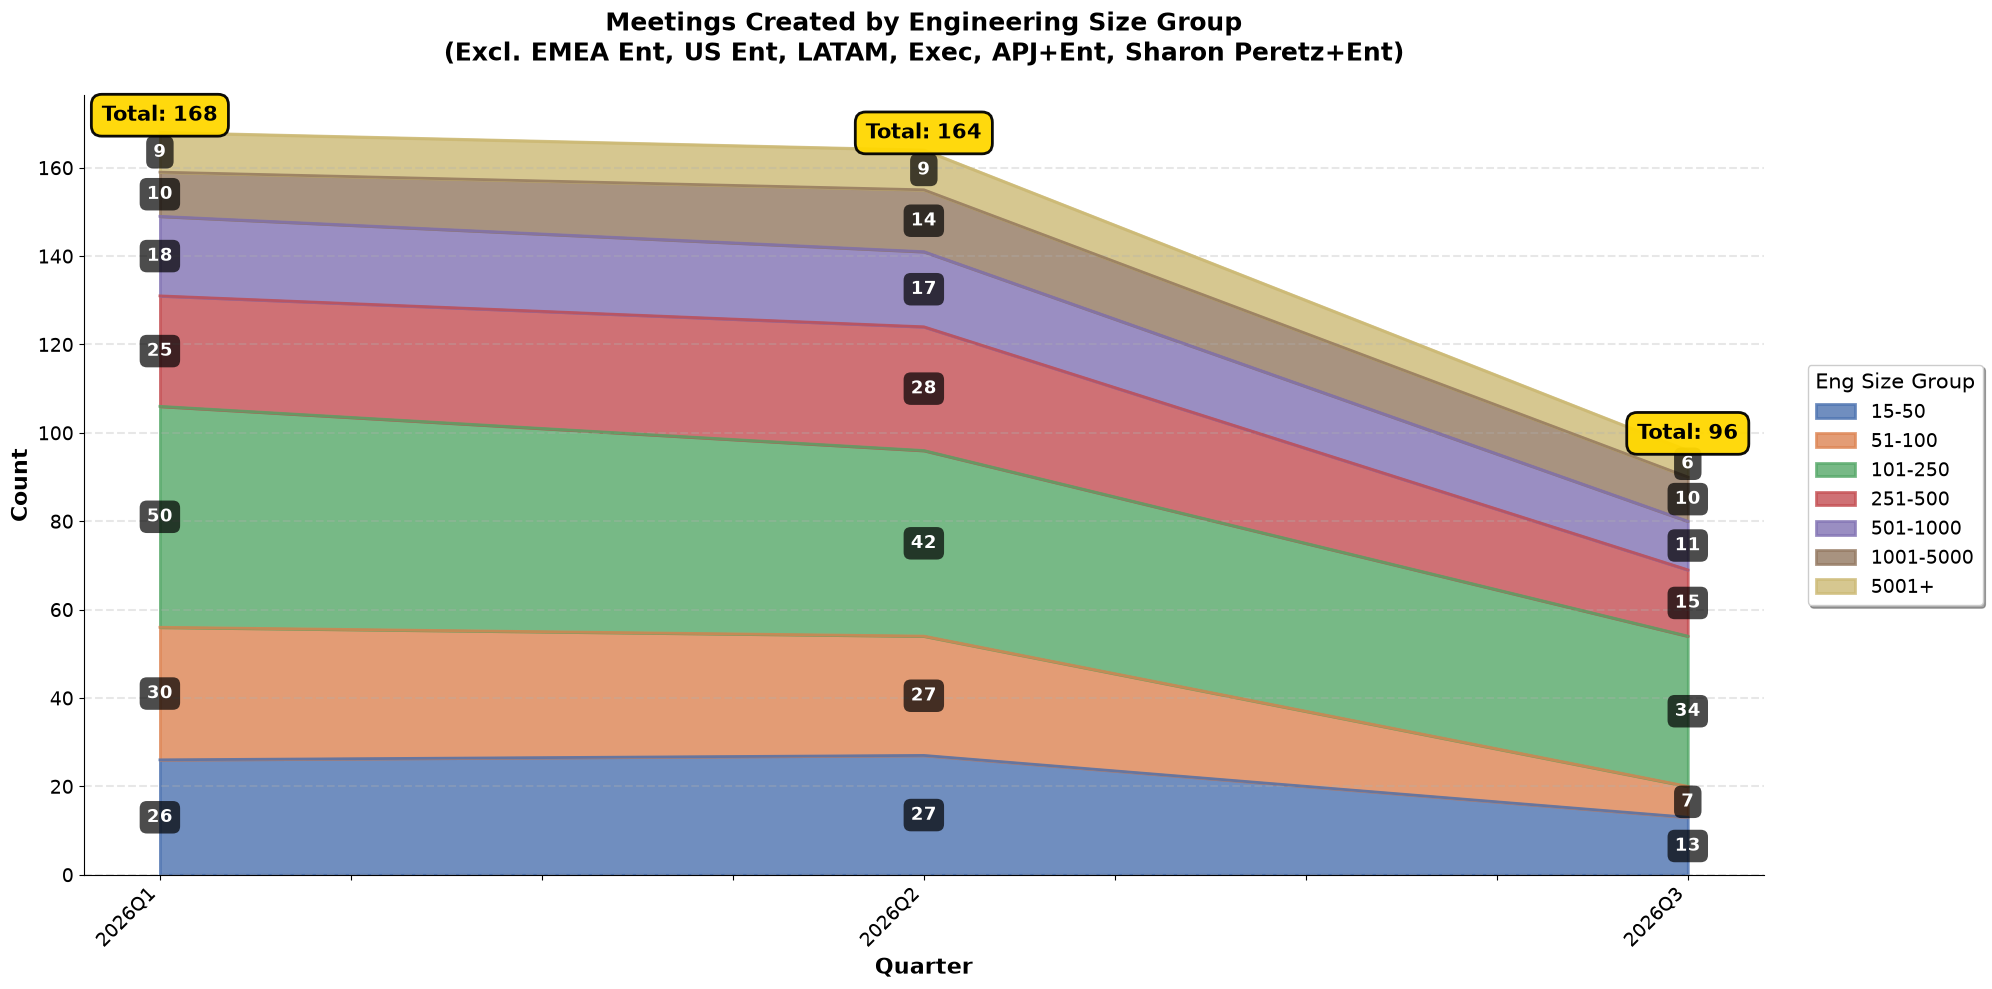


Chart saved: /Users/guyamitai/Documents/Snow/snowflake-guy/SDR Full Cycle/sdr_area_chart.png


In [95]:
# Create stacked area chart with legend on right
fig, ax = plt.subplots(figsize=(20, 10))

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3', '#937860', '#CCB974']

pivot_data.plot.area(
    ax=ax,
    stacked=True,
    color=colors[:len(pivot_data.columns)],
    alpha=0.8,
    linewidth=2
)

# Calculate cumulative values for label positioning
cumsum_data = pivot_data.cumsum(axis=1)

# Add labels for each segment in each quarter
for i, quarter in enumerate(pivot_data.index):
    prev_height = 0
    for col in pivot_data.columns:
        value = pivot_data.loc[quarter, col]
        if value > 0:  # Only label non-zero segments
            # Position label in middle of segment
            height = prev_height + (value / 2)
            ax.text(i, height, f'{int(value)}',
                   ha='center', va='center',
                   fontsize=13, fontweight='bold',
                   color='white',
                   bbox=dict(boxstyle='round,pad=0.4', 
                            facecolor='black', alpha=0.7, edgecolor='none'))
            prev_height += value
    
    # Add total at top
    total = pivot_data.loc[quarter].sum()
    ax.text(i, total + (pivot_data.values.max() * 0.03), 
            f'Total: {int(total)}',
            ha='center', va='bottom', 
            fontweight='bold', fontsize=15,
            bbox=dict(boxstyle='round,pad=0.5', 
                     facecolor='#FFD700', alpha=0.95, edgecolor='black', linewidth=2))

ax.set_title('Meetings Created by Engineering Size Group\n(Excl. EMEA Ent, US Ent, LATAM, Exec, APJ+Ent, Sharon Peretz+Ent)', 
             fontweight='bold', fontsize=18, pad=25)
ax.set_xlabel('Quarter', fontsize=16, fontweight='bold')
ax.set_ylabel('Count', fontsize=16, fontweight='bold')

# Move legend to right side, outside plot area
ax.legend(title='Eng Size Group', 
          loc='center left', 
          bbox_to_anchor=(1.02, 0.5),
          frameon=True, 
          fontsize=14, 
          title_fontsize=15, 
          shadow=True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=1.5)

plt.xticks(rotation=45, ha='right', fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()

save_path = '/Users/guyamitai/Documents/Snow/snowflake-guy/SDR Full Cycle/sdr_area_chart.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"\nChart saved: {save_path}")

Total meetings (2026, eng>=15, all teams): 831

Data for chart (ordered):
eng_size_group       15-50  51-100  101-250  251-500  501-1000  1001-5000  \
create_date_quarter                                                         
2026Q1                  26      30       66       47        47         56   
2026Q2                  30      33       57       40        28         60   
2026Q3                  16      14       51       33        36         44   

eng_size_group       5001+  
create_date_quarter         
2026Q1                  59  
2026Q2                  31  
2026Q3                  27  


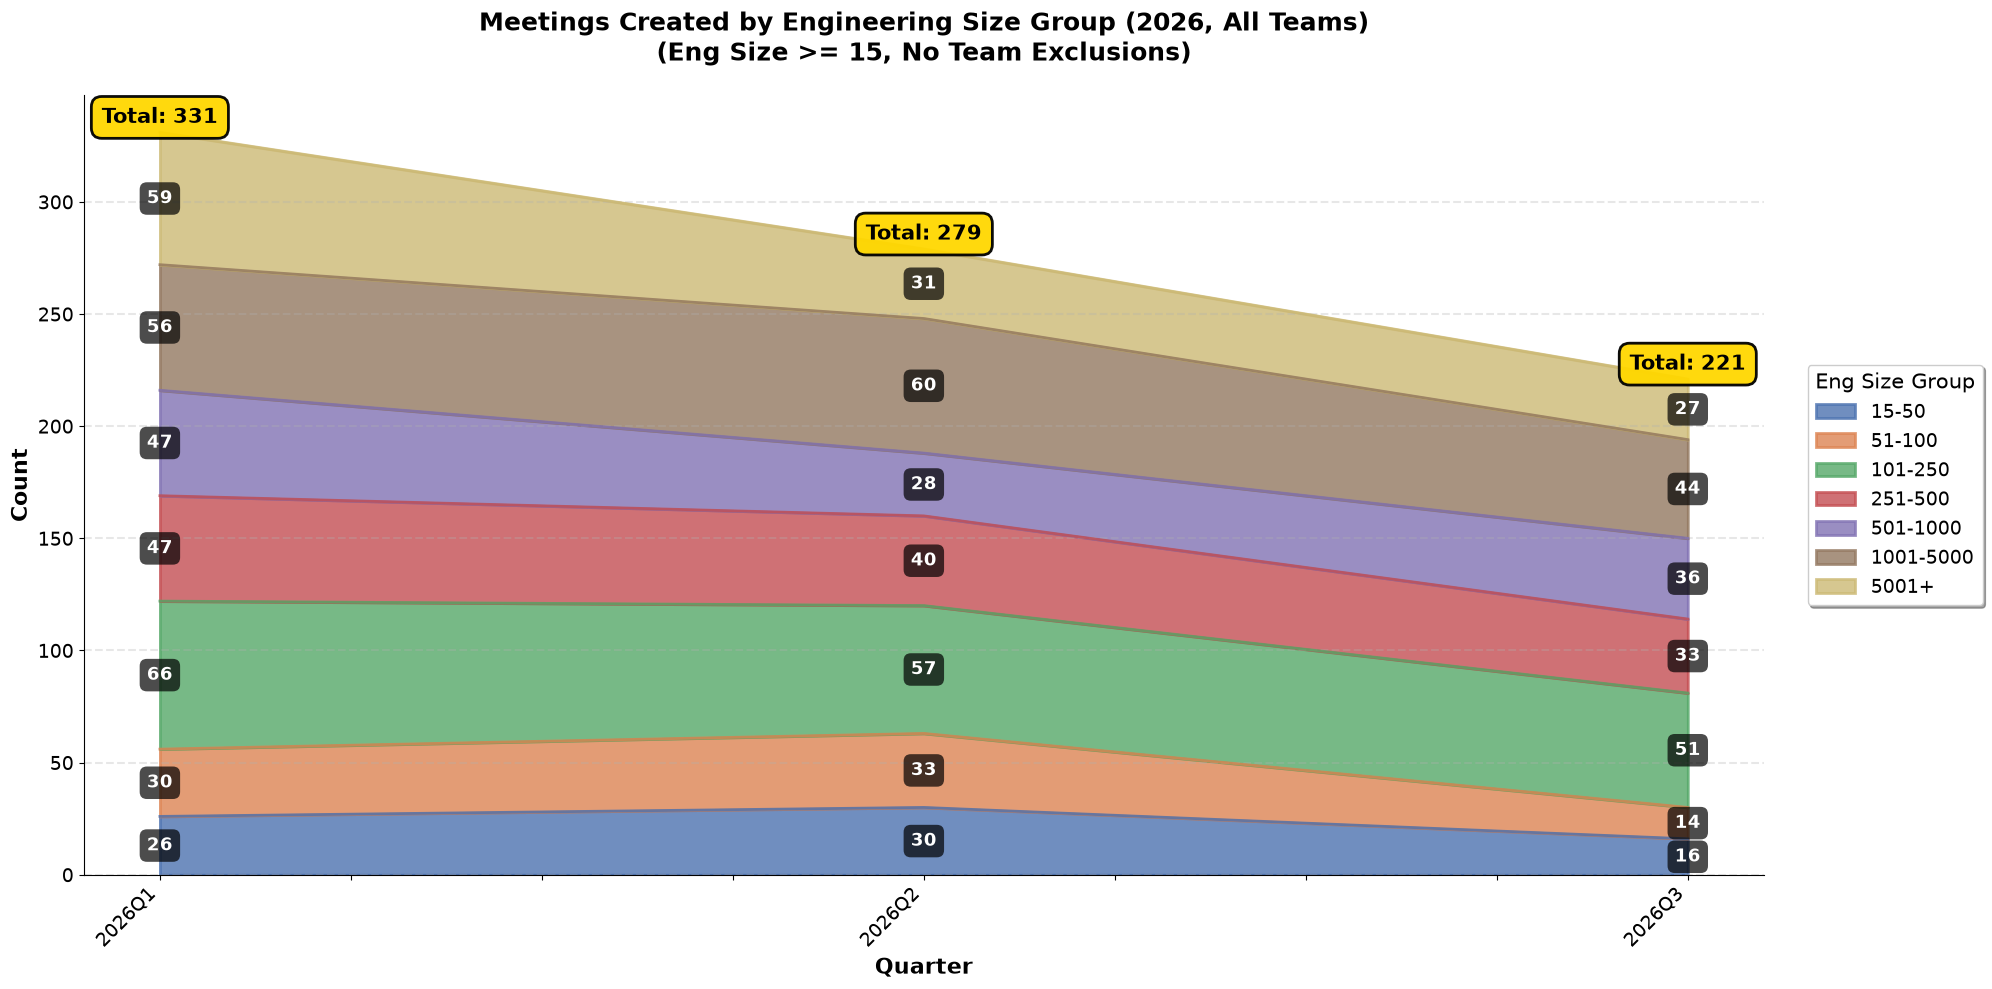


Chart saved: /Users/guyamitai/Documents/Snow/snowflake-guy/SDR Full Cycle/sdr_area_chart_2026_all_teams.png


In [96]:
# Area chart 2: ALL teams, 2026 only, eng_size >= 15
# Read fresh from CSV to bypass global exclusions
import pandas as pd
df_2026 = pd.read_csv('/Users/guyamitai/Documents/Snow/snowflake-guy/SDR Full Cycle/hubspot-crm-exports-all-deals-2026-09-23-3.csv')

# Extract eng_size
df_2026['eng_size'] = df_2026['Eng group size'].astype(str).str.extract(r'(\d+)').astype(float)
df_2026 = df_2026[df_2026['eng_size'] >= 15].copy()

# Parse Create Date and filter to 2026
df_2026['Create Date'] = pd.to_datetime(df_2026['Create Date'])
df_2026 = df_2026[df_2026['Create Date'].dt.year == 2026].copy()

# Create eng_size_group
def create_eng_size_group(size):
    if pd.isna(size):
        return None
    elif size < 51:
        return '15-50'
    elif size < 101:
        return '51-100'
    elif size < 251:
        return '101-250'
    elif size < 501:
        return '251-500'
    elif size < 1001:
        return '501-1000'
    elif size < 5001:
        return '1001-5000'
    else:
        return '5001+'

df_2026['eng_size_group'] = df_2026['eng_size'].apply(create_eng_size_group)
df_2026['create_date_quarter'] = df_2026['Create Date'].dt.to_period('Q').astype(str)

# Group and pivot
area_data_2026 = df_2026.groupby(['create_date_quarter', 'eng_size_group']).size().reset_index(name='count')
pivot_data_2026 = area_data_2026.pivot(index='create_date_quarter', columns='eng_size_group', values='count').fillna(0)

# Order columns
size_order = ['15-50', '51-100', '101-250', '251-500', '501-1000', '1001-5000', '5001+']
size_order = [col for col in size_order if col in pivot_data_2026.columns]
pivot_data_2026 = pivot_data_2026[size_order]

print(f"Total meetings (2026, eng>=15, all teams): {df_2026.shape[0]}")
print("\nData for chart (ordered):")
print(pivot_data_2026)

# Create stacked area chart
fig, ax = plt.subplots(figsize=(20, 10))

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3', '#937860', '#CCB974']

pivot_data_2026.plot.area(
    ax=ax,
    stacked=True,
    color=colors[:len(pivot_data_2026.columns)],
    alpha=0.8,
    linewidth=2
)

# Add labels for each segment
for i, quarter in enumerate(pivot_data_2026.index):
    prev_height = 0
    for col in pivot_data_2026.columns:
        value = pivot_data_2026.loc[quarter, col]
        if value > 0:
            height = prev_height + (value / 2)
            ax.text(i, height, f'{int(value)}',
                   ha='center', va='center',
                   fontsize=13, fontweight='bold',
                   color='white',
                   bbox=dict(boxstyle='round,pad=0.4', 
                            facecolor='black', alpha=0.7, edgecolor='none'))
            prev_height += value
    
    # Add total at top
    total = pivot_data_2026.loc[quarter].sum()
    ax.text(i, total + (pivot_data_2026.values.max() * 0.03), 
            f'Total: {int(total)}',
            ha='center', va='bottom', 
            fontweight='bold', fontsize=15,
            bbox=dict(boxstyle='round,pad=0.5', 
                     facecolor='#FFD700', alpha=0.95, edgecolor='black', linewidth=2))

ax.set_title('Meetings Created by Engineering Size Group (2026, All Teams)\n(Eng Size >= 15, No Team Exclusions)', 
             fontweight='bold', fontsize=18, pad=25)
ax.set_xlabel('Quarter', fontsize=16, fontweight='bold')
ax.set_ylabel('Count', fontsize=16, fontweight='bold')

ax.legend(title='Eng Size Group', 
          loc='center left', 
          bbox_to_anchor=(1.02, 0.5),
          frameon=True, 
          fontsize=14, 
          title_fontsize=15, 
          shadow=True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=1.5)

plt.xticks(rotation=45, ha='right', fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()

save_path = '/Users/guyamitai/Documents/Snow/snowflake-guy/SDR Full Cycle/sdr_area_chart_2026_all_teams.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"\nChart saved: {save_path}")

Data for bar chart:
eng_size_binary             100+  100-
hubspot_team_name_enriched            
EMEA MM                      114    43
US MM                         92    37
APJ                            7     5


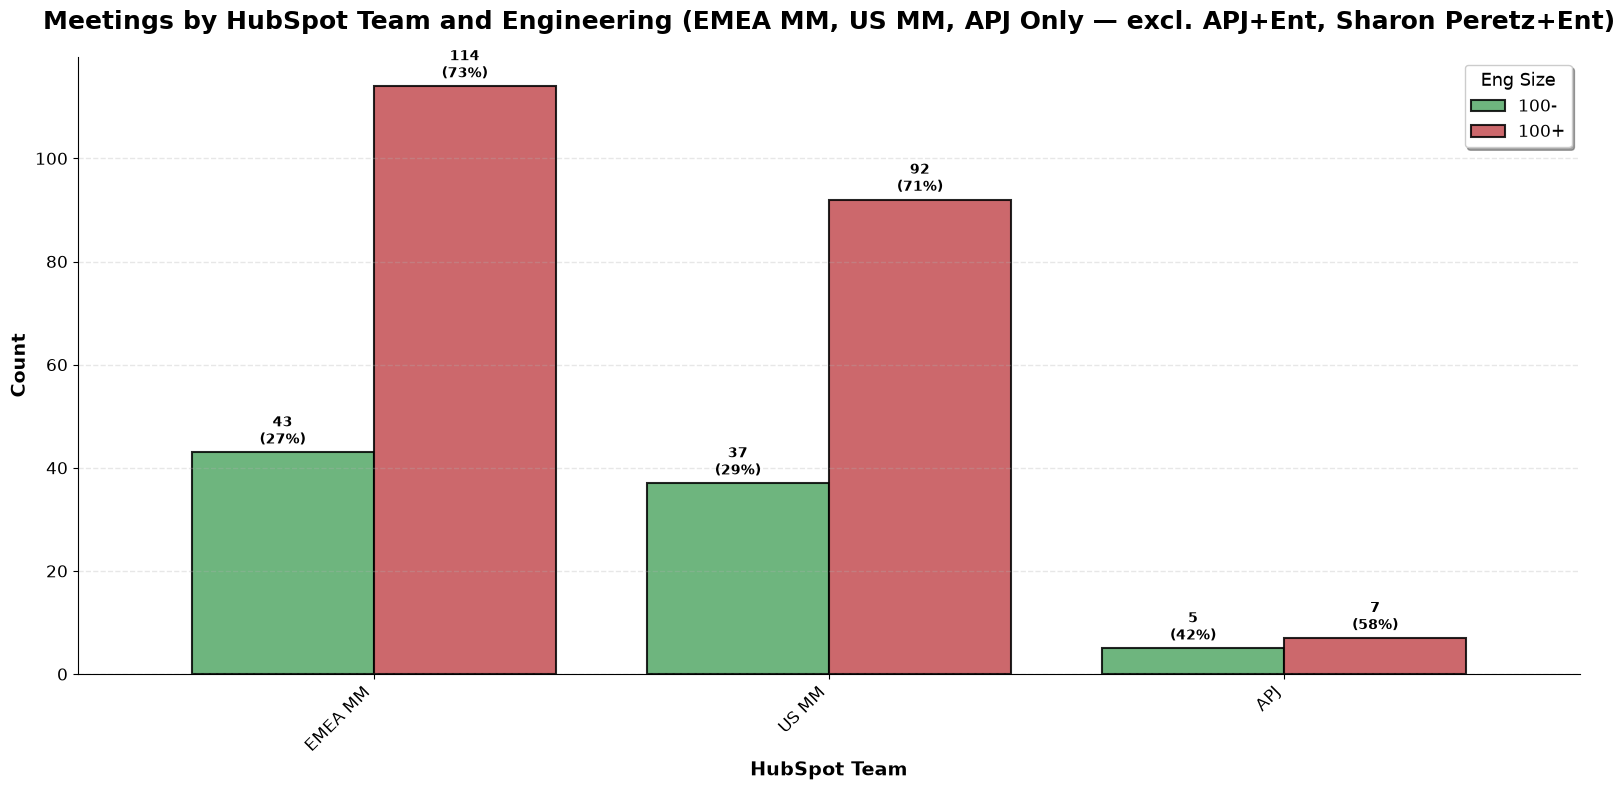


Chart saved: /Users/guyamitai/Documents/Snow/snowflake-guy/SDR Full Cycle/team_bar_chart.png


In [97]:
# Create separate filter for bar chart: EMEA MM, US MM, APJ only
bar_teams = ['EMEA MM', 'US MM', 'APJ']
df_bar = df[df['hubspot_team_name_enriched'].isin(bar_teams)].copy()

# Create binary eng_size category: 100- vs 100+
df_bar['eng_size_binary'] = df_bar['eng_size'].apply(
    lambda x: '100-' if x < 100 else '100+'
)

# Group by team and eng_size_binary
bar_data = df_bar.groupby(['hubspot_team_name_enriched', 'eng_size_binary']).size().reset_index(name='count')

# Pivot for grouped bar chart
bar_pivot = bar_data.pivot(index='hubspot_team_name_enriched', columns='eng_size_binary', values='count').fillna(0)

# Sort by total count descending
bar_pivot['total'] = bar_pivot.sum(axis=1)
bar_pivot = bar_pivot.sort_values('total', ascending=False).drop('total', axis=1)

print("Data for bar chart:")
print(bar_pivot)

# Calculate team totals for percentage
team_totals = bar_pivot.sum(axis=1)

# Create grouped bar chart
fig, ax = plt.subplots(figsize=(16, 8))

# Ensure column order: 100- first, then 100+
if '100-' in bar_pivot.columns and '100+' in bar_pivot.columns:
    bar_pivot = bar_pivot[['100-', '100+']]

bar_pivot.plot.bar(
    ax=ax,
    width=0.8,
    color=['#55A868', '#C44E52'],
    alpha=0.85,
    edgecolor='black',
    linewidth=1.5
)

# Add data labels with count and percentage of team total
for i, container in enumerate(ax.containers):
    labels = []
    for j, bar in enumerate(container):
        height = bar.get_height()
        team_name = bar_pivot.index[j]
        team_total = team_totals[team_name]
        
        if height > 0:
            pct = (height / team_total) * 100
            labels.append(f'{int(height)}\n({pct:.0f}%)')
        else:
            labels.append('')
    
    ax.bar_label(container, labels=labels, fontsize=10, fontweight='bold', padding=3)

ax.set_title('Meetings by HubSpot Team and Engineering (EMEA MM, US MM, APJ Only \u2014 excl. APJ+Ent, Sharon Peretz+Ent)', 
             fontweight='bold', fontsize=18, pad=20)
ax.set_xlabel('HubSpot Team', fontsize=14, fontweight='bold')
ax.set_ylabel('Count', fontsize=14, fontweight='bold')

ax.legend(title='Eng Size', fontsize=12, title_fontsize=13, loc='upper right', frameon=True, shadow=True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=1)

plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()

save_path = '/Users/guyamitai/Documents/Snow/snowflake-guy/SDR Full Cycle/team_bar_chart.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"\nChart saved: {save_path}")

Filtered data: 428 rows

Qualified distribution:
Qualified?
Unqualified         278
Qualified           101
Not happened yet     41
Discovery             8
Name: count, dtype: int64

Data for chart:
Qualified?               Discovery  Not happened yet  Qualified  Unqualified
eng_size_group_combined                                                     
15-100                         3.0               9.0       31.0         87.0
101-250                        0.0              10.0       40.0         76.0
251-500                        2.0               8.0       13.0         45.0
501-1000                       0.0               8.0       14.0         24.0
1001-5000                      1.0               4.0        3.0         26.0
5001+                          2.0               2.0        0.0         20.0


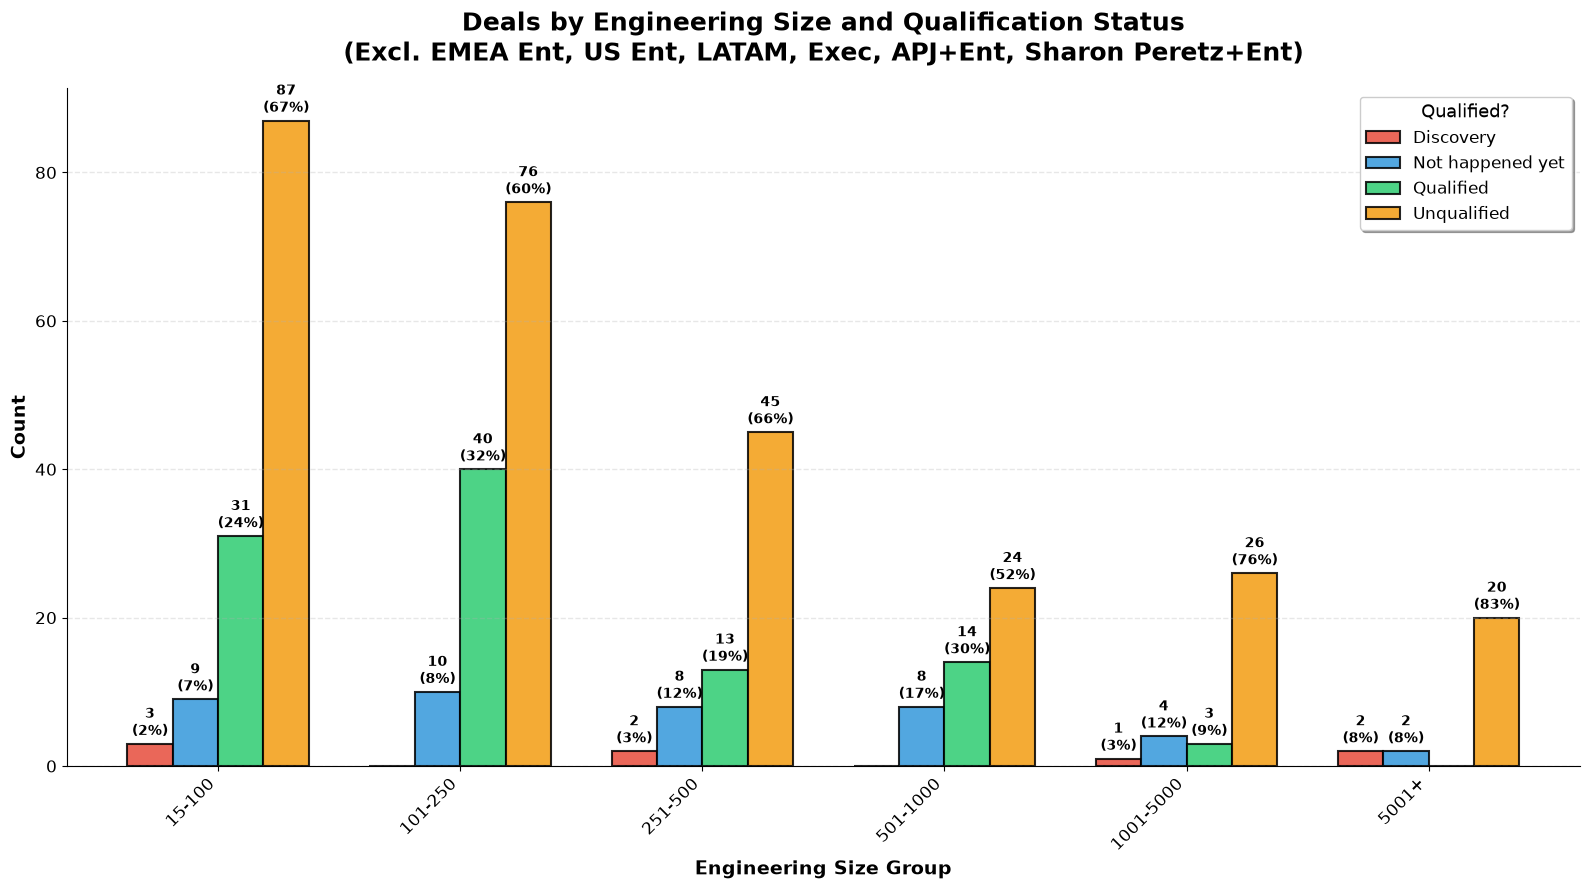


Chart saved: /Users/guyamitai/Documents/Snow/snowflake-guy/SDR Full Cycle/qualified_by_size_chart.png


In [98]:
# Create filter for qualified breakdown chart
# Filters: exclude teams, eng_size >= 15


df_qualified = df[
    (df['eng_size'] >= 15)
].copy()

print(f"Filtered data: {df_qualified.shape[0]} rows")
print(f"\nQualified distribution:")
print(df_qualified['Qualified?'].value_counts())

# Create combined size group for this chart (15-100 instead of 15-50 and 51-100)
def create_combined_size_group(group):
    if group in ['15-50', '51-100']:
        return '15-100'
    else:
        return group

df_qualified['eng_size_group_combined'] = df_qualified['eng_size_group'].apply(create_combined_size_group)

# Group by combined eng_size_group and Qualified?
qualified_data = df_qualified.groupby(['eng_size_group_combined', 'Qualified?']).size().reset_index(name='count')

# Pivot for grouped bar chart
qualified_pivot = qualified_data.pivot(index='eng_size_group_combined', columns='Qualified?', values='count').fillna(0)

# Order by eng_size_group
size_order = ['15-100', '101-250', '251-500', '501-1000', '1001-5000', '5001+']
size_order = [s for s in size_order if s in qualified_pivot.index]
qualified_pivot = qualified_pivot.reindex(size_order)

print("\nData for chart:")
print(qualified_pivot)

# Calculate size group totals for percentage
size_totals = qualified_pivot.sum(axis=1)

# Create grouped bar chart
fig, ax = plt.subplots(figsize=(16, 9))

# Sort columns to ensure consistent ordering
qualified_pivot = qualified_pivot[sorted(qualified_pivot.columns)]

qualified_pivot.plot.bar(
    ax=ax,
    width=0.75,
    color=['#E74C3C', '#3498DB', '#2ECC71', '#F39C12'],  # Red, Blue, Green, Yellow
    alpha=0.85,
    edgecolor='black',
    linewidth=1.5
)

# Add data labels with count and percentage of size group total
for i, container in enumerate(ax.containers):
    labels = []
    for j, bar in enumerate(container):
        height = bar.get_height()
        size_group = qualified_pivot.index[j]
        size_total = size_totals[size_group]
        
        if height > 0:
            pct = (height / size_total) * 100
            labels.append(f'{int(height)}\n({pct:.0f}%)')
        else:
            labels.append('')
    
    ax.bar_label(container, labels=labels, fontsize=10, fontweight='bold', padding=3)

ax.set_title('Deals by Engineering Size and Qualification Status\n(Excl. EMEA Ent, US Ent, LATAM, Exec, APJ+Ent, Sharon Peretz+Ent)', 
             fontweight='bold', fontsize=18, pad=20)
ax.set_xlabel('Engineering Size Group', fontsize=14, fontweight='bold')
ax.set_ylabel('Count', fontsize=14, fontweight='bold')

ax.legend(title='Qualified?', fontsize=12, title_fontsize=13, loc='upper right', frameon=True, shadow=True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=1)

plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()

save_path = '/Users/guyamitai/Documents/Snow/snowflake-guy/SDR Full Cycle/qualified_by_size_chart.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"\nChart saved: {save_path}")

In [99]:
# Create filter for closed lost reasons table
# Filters: Deal Stage = Closed Lost, Qualified? = 'Qualified', exclude teams, eng_size >= 15


df_lost = df[
    (df['eng_size'] >= 15) &
    (df['Qualified?'] == 'Qualified') &
    (df['Deal Stage'].str.lower().str.contains('closed lost', case=False, na=False))
].copy()

print(f"Filtered data: {df_lost.shape[0]} rows")

# Create binary eng_size category: 15-100 vs 100+
df_lost['eng_size_binary'] = df_lost['eng_size'].apply(
    lambda x: '15-100' if x <= 100 else '100+'
)

# Group by closed_lost_category and eng_size_binary
lost_data = df_lost.groupby(['closed_lost_category', 'eng_size_binary']).size().reset_index(name='count')

# Pivot to get columns for 15-100 and 100+
lost_pivot = lost_data.pivot(index='closed_lost_category', columns='eng_size_binary', values='count').fillna(0)

# Ensure both columns exist
if '15-100' not in lost_pivot.columns:
    lost_pivot['15-100'] = 0
if '100+' not in lost_pivot.columns:
    lost_pivot['100+'] = 0

# Reorder columns
lost_pivot = lost_pivot[['15-100', '100+']]

# Calculate total count for sorting
lost_pivot['total'] = lost_pivot['15-100'] + lost_pivot['100+']

# Sort by total
lost_pivot_sorted = lost_pivot.sort_values('total', ascending=False)

# Separate "Other" category if it exists from categorization
if 'Other' in lost_pivot_sorted.index:
    other_from_categorization = lost_pivot_sorted.loc[['Other']]
    lost_pivot_no_other = lost_pivot_sorted.drop('Other')
else:
    other_from_categorization = None
    lost_pivot_no_other = lost_pivot_sorted

# Get top 7 categories (excluding the categorization "Other")
top_7 = lost_pivot_no_other.head(7)
rest = lost_pivot_no_other.iloc[7:]

# Calculate combined "Other" row (remaining categories + categorization "Other")
if len(rest) > 0 or other_from_categorization is not None:
    other_15_100 = 0
    other_100_plus = 0
    other_total = 0
    
    # Add remaining categories
    if len(rest) > 0:
        other_15_100 += rest['15-100'].sum()
        other_100_plus += rest['100+'].sum()
        other_total += rest['total'].sum()
    
    # Add categorization "Other"
    if other_from_categorization is not None:
        other_15_100 += other_from_categorization['15-100'].iloc[0]
        other_100_plus += other_from_categorization['100+'].iloc[0]
        other_total += other_from_categorization['total'].iloc[0]
    
    other_row = pd.DataFrame({
        '15-100': [other_15_100],
        '100+': [other_100_plus],
        'total': [other_total]
    }, index=['Other'])
    
    # Combine top 7 with unified Other
    lost_pivot_final = pd.concat([top_7, other_row])
else:
    lost_pivot_final = top_7

# Calculate totals for each size group
total_15_100 = lost_pivot_final['15-100'].sum()
total_100_plus = lost_pivot_final['100+'].sum()

# Calculate percentages
lost_pivot_final['15-100_pct'] = (lost_pivot_final['15-100'] / total_15_100 * 100).round(1)
lost_pivot_final['100+_pct'] = (lost_pivot_final['100+'] / total_100_plus * 100).round(1)

# Create result table with only percentages
result_table = pd.DataFrame({
    '15-100': lost_pivot_final['15-100_pct'].apply(lambda x: f'{x:.1f}%'),
    '100+': lost_pivot_final['100+_pct'].apply(lambda x: f'{x:.1f}%')
}, index=lost_pivot_final.index)

print(f"\nTop {len(top_7)} Closed Lost Reason Categories + Other (% of size group)")
print(f"(Qualified Deals, Deal Stage = Closed Lost)")
print(f"Total 15-100: {int(total_15_100)} deals | Total 100+: {int(total_100_plus)} deals")
print("="*80)
print(result_table.to_string())

# Optional: Create a styled display
# Reset index to avoid non-unique index issues
result_display = result_table.reset_index()
result_display.columns = ['Closed Lost Reason', '15-100', '100+']

styled = result_display.style.set_properties(**{
    'text-align': 'center',
    'font-size': '12pt'
}).set_table_styles([
    {'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'center')]},
    {'selector': 'td', 'props': [('padding', '10px')]}
])

styled = styled.set_caption('Top Closed Lost Reasons by Engineering Size (Qualified Deals, Excl. EMEA Ent, US Ent, LATAM, Exec, APJ+Ent, Sharon Peretz+Ent)')

display(styled)

Filtered data: 56 rows

Top 7 Closed Lost Reason Categories + Other (% of size group)
(Qualified Deals, Deal Stage = Closed Lost)
Total 15-100: 15 deals | Total 100+: 41 deals
                        15-100   100+
Timing / Maturity        26.7%  31.7%
No Show / Can't Connect  26.7%  26.8%
Competitor                6.7%  19.5%
No Value / Product       13.3%  17.1%
Not a Fit                13.3%   2.4%
Budget / Price            0.0%   2.4%
Security / Compliance     6.7%   0.0%
Other                     6.7%   0.0%


,Closed Lost Reason,15-100,100+
0,Timing / Maturity,26.7%,31.7%
1,No Show / Can't Connect,26.7%,26.8%
2,Competitor,6.7%,19.5%
3,No Value / Product,13.3%,17.1%
4,Not a Fit,13.3%,2.4%
5,Budget / Price,0.0%,2.4%
6,Security / Compliance,6.7%,0.0%
7,Other,6.7%,0.0%


Filtered data: 56 rows

Stage Before Closed Distribution:
Total 15-100: 15 deals | Total 100+: 41 deals


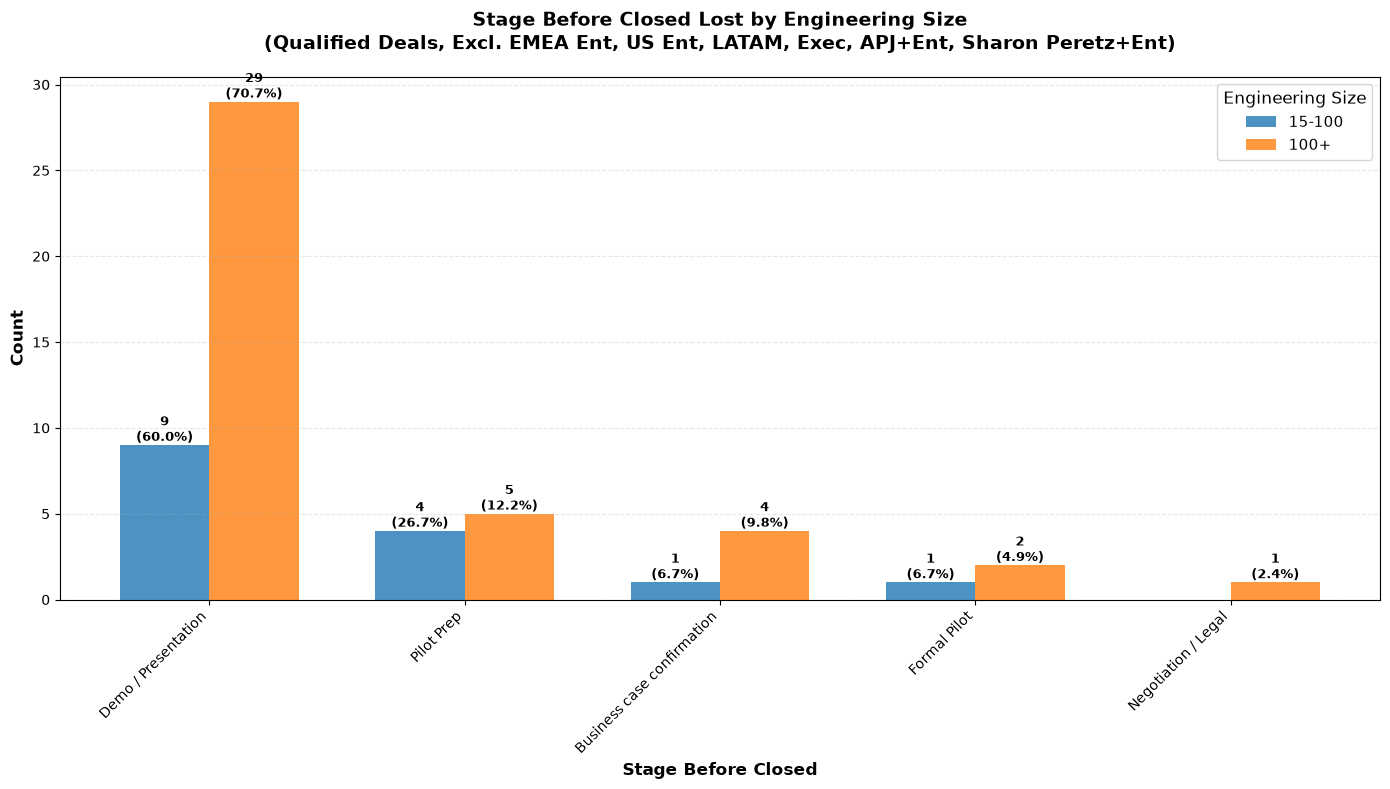


Detailed Breakdown:
                     Stage  15-100 Count 15-100 %  100+ Count 100+ %
       Demo / Presentation             9    60.0%          29  70.7%
                Pilot Prep             4    26.7%           5  12.2%
Business case confirmation             1     6.7%           4   9.8%
              Formal Pilot             1     6.7%           2   4.9%
       Negotiation / Legal             0     0.0%           1   2.4%


In [100]:
# Create filter for stage before closed chart
# Filters: Qualified, Deal Stage = Closed Lost, exclude teams


df_stage_before = df[
    (df['Qualified?'] == 'Qualified') &
    (df['Deal Stage'].str.lower().str.contains('closed lost', case=False, na=False))
].copy()

print(f"Filtered data: {df_stage_before.shape[0]} rows")

# Create binary eng_size category: 15-100 vs 100+
df_stage_before['eng_size_binary'] = df_stage_before['eng_size'].apply(
    lambda x: '15-100' if x <= 100 else '100+'
)

# Define pipeline stage order (typical sales pipeline progression)
stage_order = [
    'SDR / Omitted OPP',
    'Demo / Presentation',
    'Pilot Prep',
    'Business case confirmation',
    'Formal Pilot',
    'Negotiation / Legal'
]

# Group by stage and size
stage_data = df_stage_before.groupby(['Deal Stage Before Closed', 'eng_size_binary']).size().reset_index(name='count')

# Pivot to get columns for 15-100 and 100+
stage_pivot = stage_data.pivot(index='Deal Stage Before Closed', columns='eng_size_binary', values='count').fillna(0)

# Ensure both columns exist
if '15-100' not in stage_pivot.columns:
    stage_pivot['15-100'] = 0
if '100+' not in stage_pivot.columns:
    stage_pivot['100+'] = 0

# Reorder to match pipeline stage order
stage_pivot_ordered = pd.DataFrame()
for stage in stage_order:
    if stage in stage_pivot.index:
        stage_pivot_ordered = pd.concat([stage_pivot_ordered, stage_pivot.loc[[stage]]])

# Add any stages not in our predefined order
remaining_stages = [s for s in stage_pivot.index if s not in stage_order]
if remaining_stages:
    stage_pivot_ordered = pd.concat([stage_pivot_ordered, stage_pivot.loc[remaining_stages]])

# Calculate percentages for each size group
total_15_100 = stage_pivot_ordered['15-100'].sum()
total_100_plus = stage_pivot_ordered['100+'].sum()

stage_pivot_ordered['15-100_pct'] = (stage_pivot_ordered['15-100'] / total_15_100 * 100).round(1)
stage_pivot_ordered['100+_pct'] = (stage_pivot_ordered['100+'] / total_100_plus * 100).round(1)

print(f"\nStage Before Closed Distribution:")
print(f"Total 15-100: {int(total_15_100)} deals | Total 100+: {int(total_100_plus)} deals")
print("="*80)

# Create grouped bar chart
fig, ax = plt.subplots(figsize=(14, 8))

x = np.arange(len(stage_pivot_ordered))
width = 0.35

bars1 = ax.bar(x - width/2, stage_pivot_ordered['15-100'], width, 
               label='15-100', color='#1f77b4', alpha=0.8)
bars2 = ax.bar(x + width/2, stage_pivot_ordered['100+'], width, 
               label='100+', color='#ff7f0e', alpha=0.8)

# Add value labels on bars (count and percentage)
for i, (bar1, bar2) in enumerate(zip(bars1, bars2)):
    height1 = bar1.get_height()
    height2 = bar2.get_height()
    pct1 = stage_pivot_ordered['15-100_pct'].iloc[i]
    pct2 = stage_pivot_ordered['100+_pct'].iloc[i]
    
    if height1 > 0:
        ax.text(bar1.get_x() + bar1.get_width()/2., height1,
                f'{int(height1)}\n({pct1:.1f}%)',
                ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    if height2 > 0:
        ax.text(bar2.get_x() + bar2.get_width()/2., height2,
                f'{int(height2)}\n({pct2:.1f}%)',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

# Customize chart
ax.set_xlabel('Stage Before Closed', fontsize=12, fontweight='bold')
ax.set_ylabel('Count', fontsize=12, fontweight='bold')
ax.set_title('Stage Before Closed Lost by Engineering Size\n(Qualified Deals, Excl. EMEA Ent, US Ent, LATAM, Exec, APJ+Ent, Sharon Peretz+Ent)',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(stage_pivot_ordered.index, rotation=45, ha='right')
ax.legend(title='Engineering Size', fontsize=11, title_fontsize=12)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# Print summary table
print("\nDetailed Breakdown:")
summary = pd.DataFrame({
    'Stage': stage_pivot_ordered.index,
    '15-100 Count': stage_pivot_ordered['15-100'].astype(int),
    '15-100 %': stage_pivot_ordered['15-100_pct'].apply(lambda x: f'{x:.1f}%'),
    '100+ Count': stage_pivot_ordered['100+'].astype(int),
    '100+ %': stage_pivot_ordered['100+_pct'].apply(lambda x: f'{x:.1f}%')
})
print(summary.to_string(index=False))

Filtered data: 56 rows

Stage Before Closed by Size Group:
Total 15-100: 15 deals | Total 100+: 41 deals


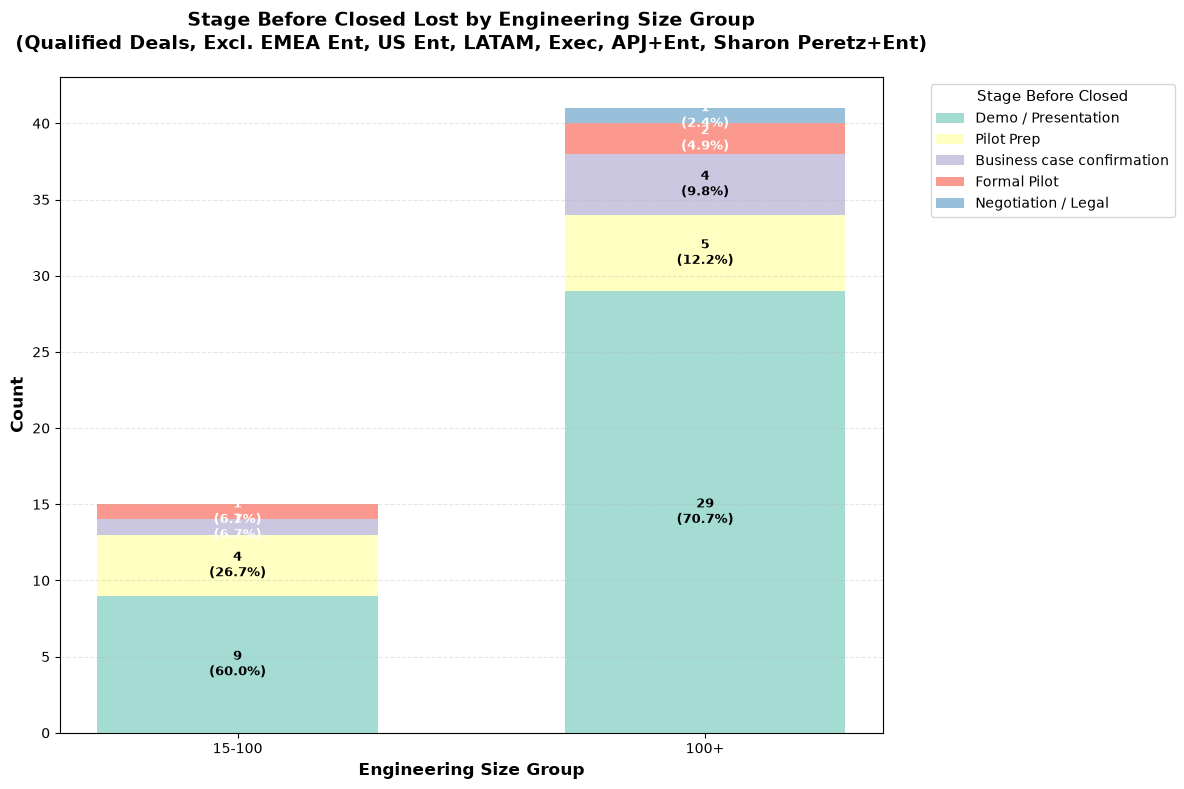


Detailed Breakdown:
Size Group                      Stage  Count Percent
    15-100        Demo / Presentation      9   60.0%
    15-100                 Pilot Prep      4   26.7%
    15-100 Business case confirmation      1    6.7%
    15-100               Formal Pilot      1    6.7%
      100+        Demo / Presentation     29   70.7%
      100+                 Pilot Prep      5   12.2%
      100+ Business case confirmation      4    9.8%
      100+               Formal Pilot      2    4.9%
      100+        Negotiation / Legal      1    2.4%


In [101]:
# Create filter for stage before closed chart (by size group)
# Filters: Qualified, Deal Stage = Closed Lost, exclude teams


df_stage_by_size = df[
    (df['Qualified?'] == 'Qualified') &
    (df['Deal Stage'].str.lower().str.contains('closed lost', case=False, na=False))
].copy()

print(f"Filtered data: {df_stage_by_size.shape[0]} rows")

# Create binary eng_size category: 15-100 vs 100+
df_stage_by_size['eng_size_binary'] = df_stage_by_size['eng_size'].apply(
    lambda x: '15-100' if x <= 100 else '100+'
)

# Define pipeline stage order (typical sales pipeline progression)
stage_order = [
    'SDR / Omitted OPP',
    'Demo / Presentation',
    'Pilot Prep',
    'Business case confirmation',
    'Formal Pilot',
    'Negotiation / Legal'
]

# Group by size and stage
stage_data = df_stage_by_size.groupby(['eng_size_binary', 'Deal Stage Before Closed']).size().reset_index(name='count')

# Pivot to get stages as columns
stage_pivot = stage_data.pivot(index='eng_size_binary', columns='Deal Stage Before Closed', values='count').fillna(0)

# Reorder columns by stage order
ordered_stages = [s for s in stage_order if s in stage_pivot.columns]
remaining_stages = [s for s in stage_pivot.columns if s not in stage_order]
all_stages = ordered_stages + remaining_stages
stage_pivot = stage_pivot[all_stages]

# Ensure both size groups exist
size_groups = ['15-100', '100+']
for sg in size_groups:
    if sg not in stage_pivot.index:
        stage_pivot.loc[sg] = 0
stage_pivot = stage_pivot.loc[size_groups]

# Calculate percentages for each size group (row)
stage_pivot_pct = stage_pivot.div(stage_pivot.sum(axis=1), axis=0) * 100

print(f"\nStage Before Closed by Size Group:")
print(f"Total 15-100: {int(stage_pivot.loc['15-100'].sum())} deals | Total 100+: {int(stage_pivot.loc['100+'].sum())} deals")
print("="*80)

# Create stacked bar chart
fig, ax = plt.subplots(figsize=(12, 8))

# Define colors for each stage (use a colormap)
colors = plt.cm.Set3(range(len(all_stages)))

x = np.arange(len(size_groups))
width = 0.6

# Create stacked bars
bottom = np.zeros(len(size_groups))
bars = []

for i, stage in enumerate(all_stages):
    values = stage_pivot[stage].values
    bar = ax.bar(x, values, width, label=stage, bottom=bottom, color=colors[i], alpha=0.8)
    bars.append(bar)
    
    # Add labels for each segment (count and percentage)
    for j, (val, pct) in enumerate(zip(values, stage_pivot_pct[stage].values)):
        if val > 0:
            # Position label in the middle of the bar segment
            label_y = bottom[j] + val / 2
            ax.text(x[j], label_y, f'{int(val)}\n({pct:.1f}%)',
                   ha='center', va='center', fontsize=9, fontweight='bold',
                   color='black' if pct > 8 else 'white')
    
    bottom += values

# Customize chart
ax.set_xlabel('Engineering Size Group', fontsize=12, fontweight='bold')
ax.set_ylabel('Count', fontsize=12, fontweight='bold')
ax.set_title('Stage Before Closed Lost by Engineering Size Group\n(Qualified Deals, Excl. EMEA Ent, US Ent, LATAM, Exec, APJ+Ent, Sharon Peretz+Ent)',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(size_groups)
ax.legend(title='Stage Before Closed', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, title_fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# Print summary table
print("\nDetailed Breakdown:")
summary_data = []
for size_group in size_groups:
    for stage in all_stages:
        count = int(stage_pivot.loc[size_group, stage])
        pct = stage_pivot_pct.loc[size_group, stage]
        if count > 0:
            summary_data.append({
                'Size Group': size_group,
                'Stage': stage,
                'Count': count,
                'Percent': f'{pct:.1f}%'
            })

summary = pd.DataFrame(summary_data)
print(summary.to_string(index=False))

In [102]:
# Create filter for qualified to close metrics
# Filters: Qualified, Deal Stage in (Closed Won), exclude teams


df_metrics = df[
    (df['Qualified?'] == 'Qualified') &
    (df['Deal Stage'].str.lower().str.contains('closed won', case=False, na=False))
].copy()

print(f"Filtered data: {df_metrics.shape[0]} rows")

# Convert dates to datetime
df_metrics['Qualified Date'] = pd.to_datetime(df_metrics['Qualified Date'], errors='coerce')
df_metrics['Close Date'] = pd.to_datetime(df_metrics['Close Date'], errors='coerce')

# Calculate days from qualified to close
df_metrics['days_qualified_to_close'] = (df_metrics['Close Date'] - df_metrics['Qualified Date']).dt.days

# Filter out invalid date calculations (negative days or missing dates)
df_metrics = df_metrics[
    (df_metrics['days_qualified_to_close'].notna()) &
    (df_metrics['days_qualified_to_close'] >= 0)
].copy()

print(f"After date validation: {df_metrics.shape[0]} rows")

# Create binary eng_size category: 15-100 vs 100+
df_metrics['eng_size_binary'] = df_metrics['eng_size'].apply(
    lambda x: '15-100' if x <= 100 else '100+'
)

# Calculate metrics by size group
metrics_summary = df_metrics.groupby('eng_size_binary').agg({
    'Amount': ['mean', 'count'],
    'days_qualified_to_close': ['median', 'mean']
}).round(2)

# Flatten column names
metrics_summary.columns = ['Avg Amount ($)', 'Deal Count', 'Median Days to Close', 'Avg Days to Close']

# Ensure both size groups exist
size_groups = ['15-100', '100+']
for sg in size_groups:
    if sg not in metrics_summary.index:
        metrics_summary.loc[sg] = [0, 0, 0, 0]

metrics_summary = metrics_summary.loc[size_groups]

# Format the amounts with commas and no decimals
metrics_display = metrics_summary.copy()
metrics_display['Avg Amount ($)'] = metrics_display['Avg Amount ($)'].apply(lambda x: f'${x:,.0f}')
metrics_display['Deal Count'] = metrics_display['Deal Count'].astype(int)
metrics_display['Median Days to Close'] = metrics_display['Median Days to Close'].apply(lambda x: f'{x:.0f} days')
metrics_display['Avg Days to Close'] = metrics_display['Avg Days to Close'].apply(lambda x: f'{x:.0f} days')

print("\n" + "="*80)
print("Qualified to Close Metrics by Engineering Size Group")
print("(Qualified Deals, Closed Won, Excl. EMEA Ent, US Ent, LATAM, Exec, APJ+Ent, Sharon Peretz+Ent)")
print("="*80)
print(metrics_display.to_string())
print("="*80)

# Create styled display
metrics_styled = metrics_display.reset_index()
metrics_styled.columns = ['Engineering Size', 'Avg Amount ($)', 'Deal Count', 'Median Days to Close', 'Avg Days to Close']

styled = metrics_styled.style.set_properties(**{
    'text-align': 'center',
    'font-size': '12pt',
    'padding': '10px'
}).set_table_styles([
    {'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'center'), ('font-size', '13pt'), ('background-color', '#f0f0f0')]},
    {'selector': 'td', 'props': [('padding', '12px'), ('border', '1px solid #ddd')]},
    {'selector': 'table', 'props': [('border-collapse', 'collapse'), ('margin', '25px 0')]}
]).hide(axis='index')

styled = styled.set_caption(
    'Qualified to Close Metrics by Engineering Size<br>'
    '<i style="font-size: 10pt; color: #666;">(Qualified Deals, Closed Won, Excl. EMEA Ent, US Ent, LATAM, Exec, APJ+Ent, Sharon Peretz+Ent)</i>'
)

display(styled)

# Additional statistics
print("\nAdditional Statistics:")
for size_group in size_groups:
    if size_group in df_metrics['eng_size_binary'].values:
        group_data = df_metrics[df_metrics['eng_size_binary'] == size_group]
        print(f"\n{size_group}:")
        print(f"  Total Amount: ${group_data['Amount'].sum():,.0f}")
        print(f"  Min Days to Close: {group_data['days_qualified_to_close'].min():.0f}")
        print(f"  Max Days to Close: {group_data['days_qualified_to_close'].max():.0f}")
        print(f"  Avg Days to Close: {group_data['days_qualified_to_close'].mean():.0f}")

Filtered data: 64 rows
After date validation: 64 rows

Qualified to Close Metrics by Engineering Size Group
(Qualified Deals, Closed Won/Lost, Excl. EMEA Ent, US Ent, LATAM, Exec, APJ+Ent, Sharon Peretz+Ent)
                Avg Amount ($)  Deal Count Median Days to Close
eng_size_binary                                                
15-100                 $39,345          20              56 days
100+                  $118,743          44              62 days


Engineering Size,Avg Amount ($),Deal Count,Median Days to Close
15-100,"$39,345",20,56 days
100+,"$118,743",44,62 days



Additional Statistics:

15-100:
  Total Amount: $786,900
  Min Days to Close: 0
  Max Days to Close: 152
  Avg Days to Close: 61

100+:
  Total Amount: $5,224,700
  Min Days to Close: 2
  Max Days to Close: 180
  Avg Days to Close: 70


In [103]:
# Cell 15: Engagement Type Analysis by Engineering Size
# Filters: Qualified, excl EMEA Ent / US Ent / LATAM / Exec / APJ+Ent / Sharon Peretz+Ent
# Format: Engagement types as rows, size groups as columns with counts and %
import snowflake.connector

conn = snowflake.connector.connect(connection_name='port-analytics-prod')
cur = conn.cursor()
cur.execute("USE WAREHOUSE ANALYTICS_DEFAULT_WH")
cur.execute("USE DATABASE PORT_ANALYTICS_PROD")
cur.execute("USE SCHEMA DWH")


df_eng_base = df[
    (df['Qualified?'] == 'Qualified')
].copy()

df_eng_base['eng_size_binary'] = df_eng_base['eng_size'].apply(
    lambda x: '15-100' if x <= 100 else '100+'
)

df_eng_base['_create'] = pd.to_datetime(df_eng_base['Create Date'], errors='coerce')
df_eng_base['_close'] = pd.to_datetime(df_eng_base['Close Date'], errors='coerce')

print(f"Filtered deals: {len(df_eng_base)}")
print(df_eng_base['eng_size_binary'].value_counts())

# Build VALUES list
rows = []
for _, r in df_eng_base.iterrows():
    if pd.isna(r['_create']) or pd.isna(r['_close']):
        continue
    rows.append(
        f"('{r['Record ID']}', '{r['_create'].date()}'::DATE, '{r['_close'].date()}'::DATE)"
    )
values_clause = ",\n        ".join(rows)
print(f"Deals with valid date window: {len(rows)}")

query = f"""
WITH deals AS (
    SELECT * FROM VALUES
        {values_clause}
    AS t(deal_crm_id, create_date, close_date)
)
SELECT
    dl.deal_crm_id           AS DEAL_CRM_ID,
    e.ENGAGEMENT_TYPE        AS ENGAGEMENT_TYPE,
    COUNT(*)                 AS ENGAGEMENT_COUNT
FROM deals dl
JOIN PORT_ANALYTICS_PROD.DWH.FACT_DEALS d
    ON d.DEAL_CRM_ID = dl.deal_crm_id
JOIN PORT_ANALYTICS_PROD.DWH.BRIDGE_ENGAGEMENT_COMPANIES bec
    ON bec.SK_COMPANY = d.SK_COMPANY
JOIN PORT_ANALYTICS_PROD.DWH.FACT_ENGAGEMENTS e
    ON e.SK_ENGAGEMENT = bec.SK_ENGAGEMENT
WHERE e.ENGAGEMENT_TYPE IN ('EMAIL', 'CALL', 'MEETING')
    AND e.ACTIVITY_AT::DATE BETWEEN dl.create_date AND dl.close_date
GROUP BY 1, 2
"""

print("Querying Snowflake...")
cur.execute(query)
df_engagements = pd.DataFrame(
    cur.fetchall(), columns=[c[0] for c in cur.description]
)
print(f"Engagement rows: {len(df_engagements)}")

# Pivot to one row per deal
df_eng_pivot = df_engagements.pivot(
    index='DEAL_CRM_ID', columns='ENGAGEMENT_TYPE', values='ENGAGEMENT_COUNT'
).reset_index()
df_eng_pivot.columns.name = None

# LEFT JOIN back
df_eng_base['_join_key'] = df_eng_base['Record ID'].astype(str)
df_eng_pivot['_join_key'] = df_eng_pivot['DEAL_CRM_ID'].astype(str)

df_eng_analysis = df_eng_base.merge(
    df_eng_pivot.drop(columns=['DEAL_CRM_ID']), on='_join_key', how='left'
)

for col in ['EMAIL', 'CALL', 'MEETING']:
    if col not in df_eng_analysis.columns:
        df_eng_analysis[col] = 0
    df_eng_analysis[col] = df_eng_analysis[col].fillna(0).astype(int)

# Pivot format: Engagement Type as rows, Size groups as columns
pivot_data = df_eng_analysis.groupby('eng_size_binary').agg({
    'EMAIL': 'sum',
    'CALL': 'sum',
    'MEETING': 'sum'
}).T

# Ensure column order: 15-100, 100+
if '15-100' not in pivot_data.columns:
    pivot_data['15-100'] = 0
if '100+' not in pivot_data.columns:
    pivot_data['100+'] = 0
pivot_data = pivot_data[['15-100', '100+']]

# Rename index
pivot_data.index = ['Emails', 'Calls', 'Meetings']
pivot_data.index.name = 'Engagement Type'

# Calculate Total column
pivot_data['Total'] = pivot_data.sum(axis=1)

# Build display table with counts and percentages
display_rows = []
for eng_type in pivot_data.index:
    row_data = {'Engagement Type': eng_type}
    
    for col in ['15-100', '100+']:
        count = int(pivot_data.loc[eng_type, col])
        total = pivot_data.loc[eng_type, 'Total']
        pct = (count / total * 100) if total > 0 else 0
        row_data[col] = f"{count:,}\n({pct:.0f}%)"
    
    row_data['Total'] = f"{int(pivot_data.loc[eng_type, 'Total']):,}"
    display_rows.append(row_data)

display_df = pd.DataFrame(display_rows)

# Rename columns for display
display_df = display_df.rename(columns={
    '15-100': '<100 Engineers',
    '100+': '100+ Engineers'
})

styled = (
    display_df.style
    .hide(axis='index')
    .set_properties(**{
        'text-align': 'center',
        'border': '1px solid #ddd',
        'padding': '10px',
        'white-space': 'pre-line'
    })
    .set_table_styles([
        {'selector': 'th', 'props': [
            ('background-color', '#4472C4'),
            ('color', 'white'),
            ('font-weight', 'bold'),
            ('text-align', 'center'),
            ('padding', '12px'),
            ('border', '1px solid #4472C4')
        ]},
        {'selector': 'td', 'props': [
            ('text-align', 'center'),
            ('padding', '10px'),
            ('border', '1px solid #ddd')
        ]},
        {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#f9f9f9')]},
        {'selector': 'caption', 'props': [
            ('font-size', '15px'),
            ('font-weight', 'bold'),
            ('padding-bottom', '10px'),
            ('caption-side', 'top')
        ]},
    ])
    .set_caption(
        'Engagement Activity by Engineering Group Size<br>'
        '<span style="font-size:12px;font-weight:normal">'
        'Qualified deals &middot; excl. EMEA Ent, US Ent, LATAM, Exec, APJ+Ent, Sharon Peretz+Ent<br>'
        'Engagements scoped to each deal\'s Create &rarr; Close window'
        '</span>'
    )
)

display(styled)

cur.close()
conn.close()

 pip install snowflake-connector-python[secure-local-storage]


Initiating login request with your identity provider. Press CTRL+C to abort and try again...
Going to open: https://sso.jumpcloud.com/saml2/psf?SAMLRequest=nZJPb%2BIwEMW%2FSuQ9EzthF4EFVCksaioKEQn9w2VlEkPdOnbW4xD67deEInUP7aE3y%2F698Zt5M7w6ltI7cANCqxEKfII8rnJdCLUfoXU26%2FSRB5apgkmt%2BAi9cUBX4yGwUlY0qu2zWvG%2FNQfruUIKaPswQrVRVDMQQBUrOVCb0zS6m9PQJ7Qy2upcS%2FRB8rWCAXBjncOLpADh7D1bW1GMm6bxm66vzR6HhBBMBthRJ%2BTHhT%2B6nj7hA0x%2BnnhHODx593Yt1HkEX9naniGgN1mWdJJlmiEvulidaAV1yU3KzUHkfL2anw2Ac5Dc3l8v099Ossr%2BRIto%2FpTFk9QHpZudZK8812VVW1fadye84wWWei9c9%2FF0hKpXUWS3h30iurPHwL5MF4vezdNmWVVhvr6L2La7PRwfNpWUDyz%2BpXPk3V%2FiDU%2FxxgA1j9UpVOuuSNjrkEEnHGSkT7t9GhC%2F1xtskDd1oQrFbKu8OAfQ%2FktdVrnUddG6O6UX4gp26LwVtK1vxt%2FqdYg%2FlnjfsoUbfDxNtBT5mzfTpmT281wCP2hvRNHZtSjlJRMyKgrDAVw%2BUupmYjizbpmtqTnC4%2FOv%2F6%2Fz%2BB8%3D&RelayState=ver%3A3-hint%3A5187783639150602-ETMsDgAAAaDsUHPtABRBRVMvQ0JDL1BLQ1M1UGFkZGluZwEAABAAEPa0%2BkyvY4vXxgE5ajSJzA4AAACgfd75y0XhK7Q2KNyUug8xZWgtR%2BwGuKied4SyRv3PF2yktTfMBLVDc3S5Aid7QSC%

 pip install snowflake-connector-python[secure-local-storage]


Filtered deals: 101
eng_size_binary
100+      70
15-100    31
Name: count, dtype: int64
Deals with valid date window: 101
Querying Snowflake...
Engagement rows: 251


Engagement Type,<100 Engineers,100+ Engineers,Total
Emails,734 (24%),"2,389 (76%)","3,123"
Calls,65 (18%),304 (82%),369
Meetings,295 (29%),737 (71%),"1,032"


In [104]:
# Deal Count Analysis
# 1. Created deals (not qualified, not closed)
# 2. Qualified deals (not closed, excl. EMEA Ent/US Ent/LATAM/Exec/APJ+Ent/Sharon Peretz+Ent)


# Group 1: Created deals - Not Qualified, Not Closed
df_created = df[
    (df['Qualified?'] != 'Qualified') &
    (~df['Deal Stage'].isin(['Closed Won', 'Closed Lost']))
].copy()

total_created = len(df_created)
created_15_100 = len(df_created[df_created['eng_size'] <= 100])

print("=" * 60)
print("GROUP 1: Created Deals (Not Qualified, Not Closed) [global exclusions applied]")
print("=" * 60)
print(f"Total deals: {total_created:,}")
print(f"  - 15-100 engineers: {created_15_100:,} ({created_15_100/total_created*100:.1f}%)")
print(f"  - 100+ engineers: {total_created - created_15_100:,} ({(total_created - created_15_100)/total_created*100:.1f}%)")
print()

# Group 2: Qualified deals - Not Closed, Excluding teams
df_qualified = df[
    (df['Qualified?'] == 'Qualified') &
    (~df['Deal Stage'].isin(['Closed Won', 'Closed Lost']))
].copy()

total_qualified = len(df_qualified)
qualified_15_100 = len(df_qualified[df_qualified['eng_size'] <= 100])

print("=" * 60)
print("GROUP 2: Qualified Deals (Not Closed, excl. EMEA Ent/US Ent/LATAM/Exec/APJ+Ent/Sharon Peretz+Ent)")
print("=" * 60)
print(f"Total deals: {total_qualified:,}")
print(f"  - 15-100 engineers: {qualified_15_100:,} ({qualified_15_100/total_qualified*100:.1f}%)")
print(f"  - 100+ engineers: {total_qualified - qualified_15_100:,} ({(total_qualified - qualified_15_100)/total_qualified*100:.1f}%)")
print()

# ---- Separate breakdowns: Sharon Peretz & APJ (ALL qualified, not-closed) ----
# Built from unfiltered CSV so globally-excluded rows are counted in full
_dfu = pd.read_csv('/Users/guyamitai/Documents/Snow/snowflake-guy/SDR Full Cycle/hubspot-crm-exports-all-deals-2026-09-23-3.csv')
_dfu['eng_size'] = _dfu['Eng group size'].astype(str).str.extract(r'(\d+)').astype(float)
_dfu = _dfu[_dfu['eng_size'] >= 15].copy()
_dfu['HubSpot Team'] = _dfu['HubSpot Team'].astype(str)
_dfu['hubspot_team_name_enriched'] = _dfu['HubSpot Team'].map(team_mapping).fillna(_dfu['HubSpot Team'])
_qu = _dfu[(_dfu['Qualified?'] == 'Qualified') & (~_dfu['Deal Stage'].isin(['Closed Won', 'Closed Lost']))].copy()

def _brk(label, sub):
    tot = len(sub)
    lo = len(sub[sub['eng_size'] <= 100])
    print('=' * 60)
    print(label)
    print('=' * 60)
    print(f'Total deals: {tot:,}')
    if tot:
        print(f'  - 15-100 engineers: {lo:,} ({lo/tot*100:.1f}%)')
        print(f'  - 100+ engineers: {tot-lo:,} ({(tot-lo)/tot*100:.1f}%)')
    else:
        print('  - 15-100 engineers: 0')
        print('  - 100+ engineers: 0')
    print()

_sharon = _qu[_qu['Deal owner'].astype(str).str.contains('Sharon Peretz', case=False, na=False)]
_brk('SEPARATE: Sharon Peretz - All Qualified, Not Closed', _sharon)

_apj = _qu[_qu['hubspot_team_name_enriched'] == 'APJ']
_brk('SEPARATE: APJ - All Qualified, Not Closed', _apj)


GROUP 1: Created Deals (Not Qualified, Not Closed) [global exclusions applied]
Total deals: 45
  - 15-100 engineers: 10 (22.2%)
  - 100+ engineers: 35 (77.8%)

GROUP 2: Qualified Deals (Not Closed, excl. EMEA Ent/US Ent/LATAM/Exec/APJ+Ent/Sharon Peretz+Ent)
Total deals: 37
  - 15-100 engineers: 11 (29.7%)
  - 100+ engineers: 26 (70.3%)

SEPARATE: Sharon Peretz - All Qualified, Not Closed
Total deals: 3
  - 15-100 engineers: 1 (33.3%)
  - 100+ engineers: 2 (66.7%)

SEPARATE: APJ - All Qualified, Not Closed
Total deals: 0
  - 15-100 engineers: 0
  - 100+ engineers: 0



In [105]:
# Diagnostic: Check qualified and closed lost data


# Start with base filter
df_diag = df[
    (df['eng_size'] >= 15)
].copy()

print(f"Base filtered data: {df_diag.shape[0]} rows")
print("\n" + "="*80)

# Check Qualified? values
print("\nQualified? distribution:")
print(df_diag['Qualified?'].value_counts(dropna=False))

# Check Deal Stage values
print("\n" + "="*80)
print("\nDeal Stage distribution:")
print(df_diag['Deal Stage'].value_counts(dropna=False).head(10))

# Create binary eng_size
df_diag['eng_size_binary'] = df_diag['eng_size'].apply(
    lambda x: '15-100' if x <= 100 else '100+'
)

# Check qualified by eng_size
print("\n" + "="*80)
print("\nQualified? by eng_size_binary:")
qual_by_size = df_diag.groupby(['eng_size_binary', 'Qualified?']).size().reset_index(name='count')
qual_pivot = qual_by_size.pivot(index='Qualified?', columns='eng_size_binary', values='count').fillna(0)
print(qual_pivot)

# Filter for Qualified only
df_qualified = df_diag[df_diag['Qualified?'] == 'Qualified'].copy()
print(f"\n\nQualified deals: {df_qualified.shape[0]} rows")

# Check Deal Stage for qualified deals
print("\nDeal Stage for Qualified deals:")
stage_by_size = df_qualified.groupby(['eng_size_binary', 'Deal Stage']).size().reset_index(name='count')
print(stage_by_size.sort_values('count', ascending=False).head(20))

# Check closed lost specifically
print("\n" + "="*80)
df_closed_lost = df_qualified[
    df_qualified['Deal Stage'].str.lower().str.contains('closed lost', case=False, na=False)
].copy()
print(f"\nQualified + Closed Lost deals: {df_closed_lost.shape[0]} rows")
print("\nBy eng_size_binary:")
print(df_closed_lost['eng_size_binary'].value_counts())

Base filtered data: 428 rows


Qualified? distribution:
Qualified?
Unqualified         278
Qualified           101
Not happened yet     41
Discovery             8
Name: count, dtype: int64


Deal Stage distribution:
Deal Stage
Closed Lost                   338
SDR / Omitted  Opp             28
SDR Discovery                  17
Demo / Presentation            16
Business Validation            10
Closed Won                      8
Business Case Confirmation      6
Formal Pilot                    3
Negotiation / Legal             2
Name: count, dtype: int64


Qualified? by eng_size_binary:
eng_size_binary   100+  15-100
Qualified?                    
Discovery            5       3
Not happened yet    32       9
Qualified           70      31
Unqualified        191      87


Qualified deals: 101 rows

Deal Stage for Qualified deals:
   eng_size_binary                  Deal Stage  count
2             100+                 Closed Lost     41
8           15-100                 Closed Lost     15

In [106]:
# Deals/meetings with eng group size > 1000
df_large = df[df['eng_size'] > 1000][
    ['Deal Name', 'hubspot_team_name_enriched', 'Deal owner', 'eng_size']
].copy()
df_large.columns = ['Deal Name', 'HubSpot Team', 'Deal Owner', 'Eng Group Size']
df_large = df_large.sort_values('Eng Group Size', ascending=False).reset_index(drop=True)

print(f"Meetings with eng group size > 1000 (global exclusions applied): {len(df_large)}")
display(df_large)

Meetings with eng group size > 1000 (global exclusions applied): 58


,Deal Name,HubSpot Team,Deal Owner,Eng Group Size
0,HCL Technologies Limited - New Deal,SDR EMEA,Adrian Sandu,120000.0
1,Cognizant,Channel,Johana Ochoa,117000.0
2,Tata Consultancy Services Ltd,Channel,Johana Ochoa,100000.0
3,KubeCon EU 2026 - Amazon,SDR EMEA,Adrian Sandu,100000.0
4,Capgemini,SDR US,Logan Loisel,80000.0
5,Intel,Channel,Johana Ochoa,51000.0
6,Intel,SDR US,Rachel Jean,33082.0
7,NVIDIA,SDR US,Rachel Jean,22524.0
8,Ericsson - New Deal,SDR EMEA,Adrian Sandu,15336.0
9,Morgan Stanley,SDR US,Dylan Leija,14839.0
